In [6]:
pip install pandas matplotlib seaborn numpy

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\User\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [7]:
# Naive Bayes Classifier - Evaluation on Inflammation Diagnosis Dataset
# PROJECT 1: NAIVE BAYES CLASSIFIER

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from naive_bayes_classifier import NaiveBayes

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [8]:
# ============================================================================
# 1. DATA LOADING AND PREPROCESSING
# ============================================================================

# Load the data
data = pd.read_csv('inflammation_diagnosis.csv', sep=';')

print("=" * 80)
print("ORIGINAL DATASET")
print("=" * 80)
print(f"Shape: {data.shape}")
print(f"\nFirst 5 rows:")
print(data.head())
print(f"\nData types:")
print(data.dtypes)
print(f"\nColumn names: {list(data.columns)}")

ORIGINAL DATASET
Shape: (120, 8)

First 5 rows:
   temperature nausea lumbar_pain urine_pushing micturition_pains  \
0         35.5     no         yes            no                no   
1         35.9     no          no           yes               yes   
2         35.9     no         yes            no                no   
3         36.0     no          no           yes               yes   
4         36.0     no         yes            no                no   

  burning_of_urethra inflammation nephritis  
0                 no           no        no  
1                yes          yes        no  
2                 no           no        no  
3                yes          yes        no  
4                 no           no        no  

Data types:
temperature           float64
nausea                 object
lumbar_pain            object
urine_pushing          object
micturition_pains      object
burning_of_urethra     object
inflammation           object
nephritis              object
dtype: o

In [9]:
# ============================================================================
# 2. CREATE COMBINED 'DISEASE' COLUMN
# ============================================================================

# Combine inflammation and nephritis columns
# True if either inflammation OR nephritis is 'yes', False otherwise
data['disease'] = ((data['inflammation'] == 'yes') | (data['nephritis'] == 'yes'))

# Drop original columns
data = data.drop(columns=['inflammation', 'nephritis'])

print("\n" + "=" * 80)
print("PREPROCESSED DATASET")
print("=" * 80)
print(f"New shape: {data.shape}")
print(f"\nFirst 5 rows with 'disease' column:")
print(data.head())
print(f"\nDisease distribution:")
print(data['disease'].value_counts())



PREPROCESSED DATASET
New shape: (120, 7)

First 5 rows with 'disease' column:
   temperature nausea lumbar_pain urine_pushing micturition_pains  \
0         35.5     no         yes            no                no   
1         35.9     no          no           yes               yes   
2         35.9     no         yes            no                no   
3         36.0     no          no           yes               yes   
4         36.0     no         yes            no                no   

  burning_of_urethra  disease  
0                 no    False  
1                yes     True  
2                 no    False  
3                yes     True  
4                 no    False  

Disease distribution:
disease
True     90
False    30
Name: count, dtype: int64


In [10]:
# ============================================================================
# 3. TRAIN-TEST SPLIT
# ============================================================================

# Shuffle the data
data_shuffled = data.sample(frac=1, random_state=42).reset_index(drop=True)

# Split: 80% train, 20% test
split_idx = int(0.8 * len(data_shuffled))
train_data = data_shuffled[:split_idx].copy()
test_data = data_shuffled[split_idx:].copy()

print("\n" + "=" * 80)
print("TRAIN-TEST SPLIT")
print("=" * 80)
print(f"Total samples: {len(data_shuffled)}")
print(f"Training samples: {len(train_data)} ({len(train_data)/len(data_shuffled)*100:.1f}%)")
print(f"Test samples: {len(test_data)} ({len(test_data)/len(data_shuffled)*100:.1f}%)")

# Verify no train samples in test set
train_indices = set(train_data.index)
test_indices = set(test_data.index)
overlap = train_indices.intersection(test_indices)

print(f"\n{'✓' if len(overlap) == 0 else '✗'} Verification: No overlap between train and test sets")
print(f"  Overlapping samples: {len(overlap)}")

# Distribution in train and test sets
print(f"\nDisease distribution in training set:")
print(train_data['disease'].value_counts(normalize=True))
print(f"\nDisease distribution in test set:")
print(test_data['disease'].value_counts(normalize=True))



TRAIN-TEST SPLIT
Total samples: 120
Training samples: 96 (80.0%)
Test samples: 24 (20.0%)

✓ Verification: No overlap between train and test sets
  Overlapping samples: 0

Disease distribution in training set:
disease
True     0.760417
False    0.239583
Name: proportion, dtype: float64

Disease distribution in test set:
disease
True     0.708333
False    0.291667
Name: proportion, dtype: float64


In [11]:
# ============================================================================
# 4. NAIVE BAYES CLASSIFIER TRAINING
# ============================================================================

# Define which features are continuous
# temperature is continuous, all others are discrete
feature_columns = [col for col in train_data.columns if col != 'disease']
continuous_features = [col == 'temperature' for col in feature_columns]

print("\n" + "=" * 80)
print("FEATURE TYPES")
print("=" * 80)
for feat, is_cont in zip(feature_columns, continuous_features):
    feat_type = "Continuous" if is_cont else "Discrete"
    print(f"  {feat:25} -> {feat_type}")

# Initialize and train the classifier
print("\n" + "=" * 80)
print("TRAINING NAIVE BAYES CLASSIFIER")
print("=" * 80)

nb_classifier = NaiveBayes(continuous=continuous_features)
nb_classifier.fit(train_data, target_name='disease')

print("✓ Training completed!")
print(f"\nClasses found: {nb_classifier.classes}")
print(f"Class priors:")
for cls, prior in nb_classifier.class_priors.items():
    print(f"  P({cls}) = {prior:.4f}")


FEATURE TYPES
  temperature               -> Continuous
  nausea                    -> Discrete
  lumbar_pain               -> Discrete
  urine_pushing             -> Discrete
  micturition_pains         -> Discrete
  burning_of_urethra        -> Discrete

TRAINING NAIVE BAYES CLASSIFIER
✓ Training completed!

Classes found: [ True False]
Class priors:
  P(True) = 0.7604
  P(False) = 0.2396


In [12]:
# ============================================================================
# 5. EVALUATION ON TEST SET
# ============================================================================

print("\n" + "=" * 80)
print("EVALUATION ON TEST SET")
print("=" * 80)

accuracy, confusion_matrix = nb_classifier.evaluate_on_data(test_data, 'disease')

print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nConfusion Matrix (Raw Counts):")
print("-" * 40)
cm_df = pd.DataFrame(confusion_matrix).T
print(cm_df)


EVALUATION ON TEST SET

Overall Accuracy: 1.0000 (100.00%)

Confusion Matrix (Raw Counts):
----------------------------------------
       True   False
True      17      0
False      0      7


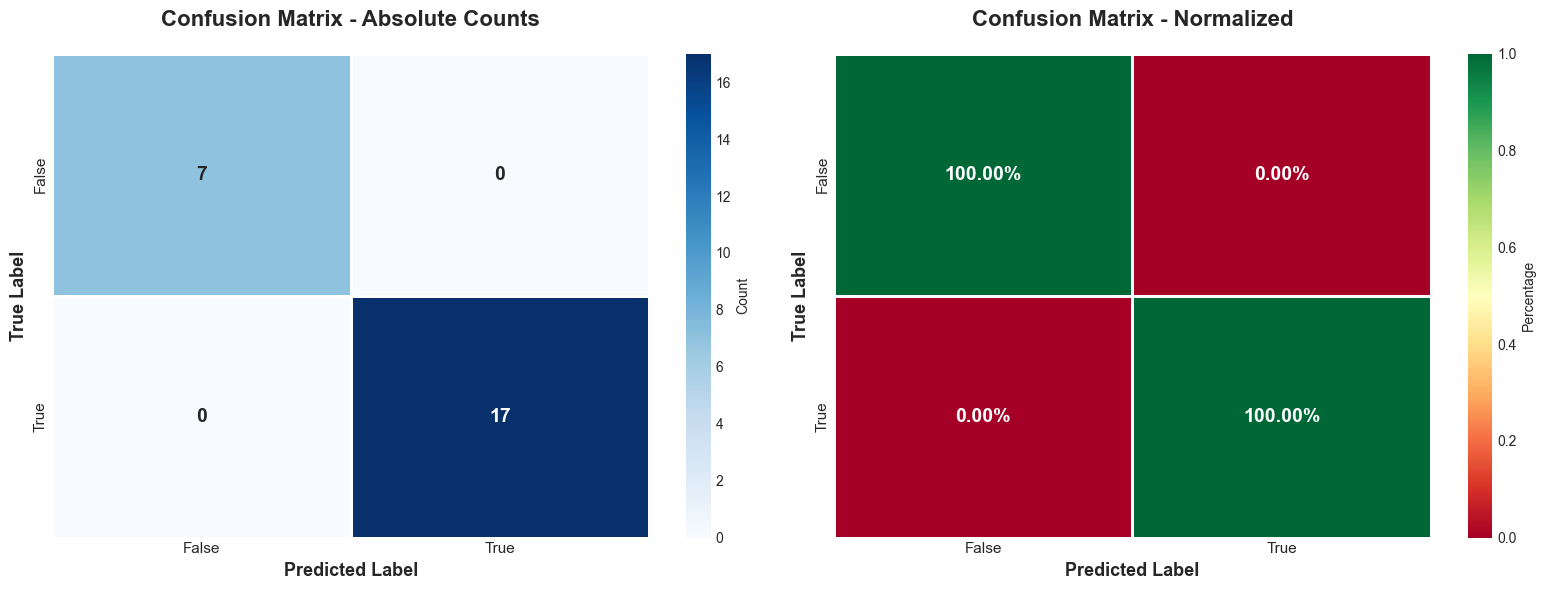

In [13]:
# ============================================================================
# 6. VISUALIZATION: CONFUSION MATRIX
# ============================================================================

# Create a more detailed visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Convert confusion matrix to array for plotting
classes = sorted(nb_classifier.classes)
cm_array = np.array([[confusion_matrix[true_cls][pred_cls] 
                      for pred_cls in classes] 
                     for true_cls in classes])

# Plot 1: Absolute counts
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'}, ax=axes[0],
            linewidths=2, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix - Absolute Counts', 
                  fontsize=16, fontweight='bold', pad=20)
axes[0].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=13, fontweight='bold')
axes[0].tick_params(labelsize=11)

# Plot 2: Normalized (percentage)
cm_normalized = cm_array.astype('float') / cm_array.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', 
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Percentage'}, ax=axes[1],
            linewidths=2, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'},
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix - Normalized', 
                  fontsize=16, fontweight='bold', pad=20)
axes[1].set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=13, fontweight='bold')
axes[1].tick_params(labelsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# ============================================================================
# 7. ADDITIONAL METRICS
# ============================================================================

print("\n" + "=" * 80)
print("DETAILED CLASSIFICATION METRICS")
print("=" * 80)

for cls in classes:
    tp = confusion_matrix[cls][cls]
    fp = sum(confusion_matrix[other_cls][cls] for other_cls in classes if other_cls != cls)
    fn = sum(confusion_matrix[cls][other_cls] for other_cls in classes if other_cls != cls)
    tn = sum(confusion_matrix[other_true][other_pred] 
             for other_true in classes if other_true != cls
             for other_pred in classes if other_pred != cls)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\nClass: {cls}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1_score:.4f}")


DETAILED CLASSIFICATION METRICS

Class: False
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

Class: True
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000


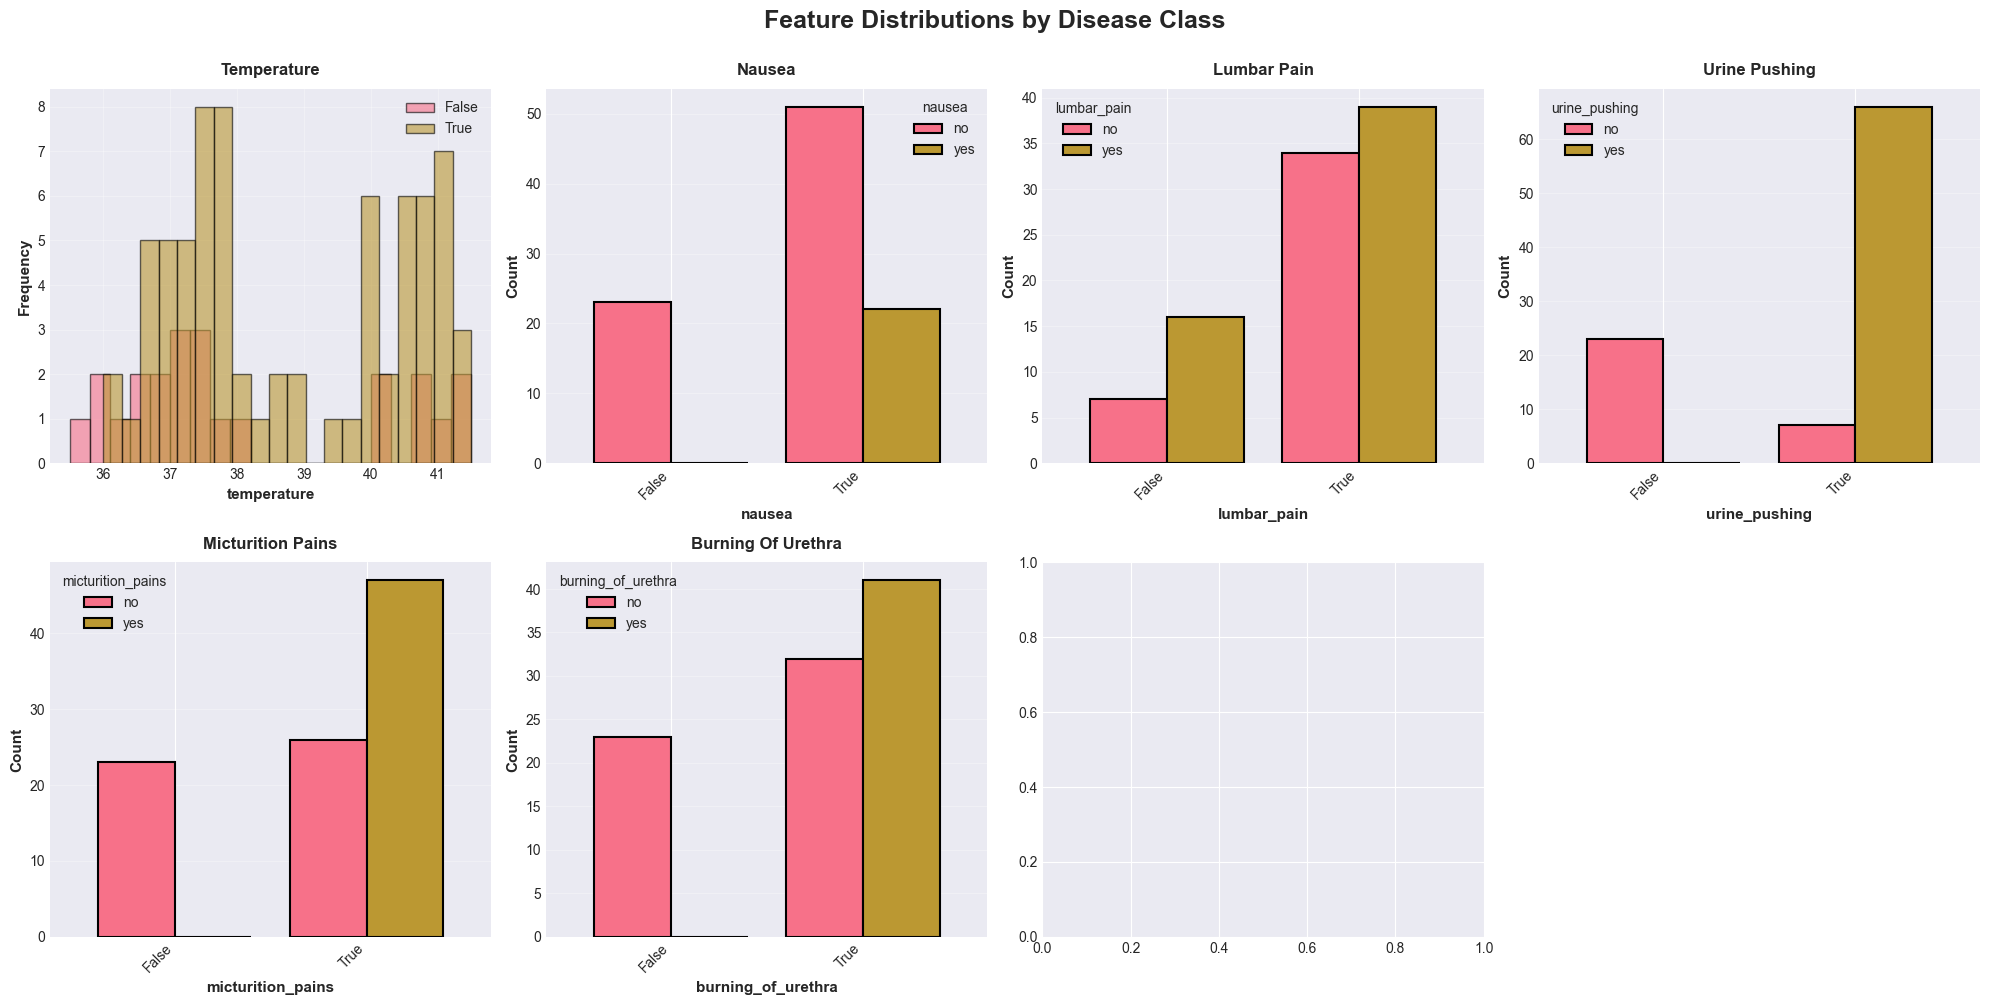


ANALYSIS COMPLETE
Visualizations saved:
  - confusion_matrix.png
  - feature_distributions.png


In [15]:
# ============================================================================
# 8. FEATURE IMPORTANCE VISUALIZATION
# ============================================================================

# Create a visualization of feature statistics per class
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, feature in enumerate(feature_columns):
    ax = axes[idx]
    
    if continuous_features[idx]:
        # For continuous feature (temperature), show distributions
        for cls in classes:
            class_data = train_data[train_data['disease'] == cls][feature]
            ax.hist(class_data, alpha=0.6, label=f'{cls}', bins=20, edgecolor='black')
        ax.set_xlabel(feature, fontsize=11, fontweight='bold')
        ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        # For discrete features, show bar charts
        counts = train_data.groupby(['disease', feature]).size().unstack(fill_value=0)
        counts.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=1.5)
        ax.set_xlabel(feature, fontsize=11, fontweight='bold')
        ax.set_ylabel('Count', fontsize=11, fontweight='bold')
        ax.legend(title=feature)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    ax.set_title(f'{feature.replace("_", " ").title()}', 
                 fontsize=12, fontweight='bold', pad=10)

# Remove empty subplot
if len(feature_columns) < len(axes):
    fig.delaxes(axes[-1])

plt.suptitle('Feature Distributions by Disease Class', 
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)
print("Visualizations saved:")
print("  - confusion_matrix.png")
print("  - feature_distributions.png")